# 6 · Lab: Heralded Fock-State Preparation

**Simulation lab, part 2 · Wednesday July 29, 11:30–12:30 · small groups**

Monday you *described* Fock states, Tuesday you learned to *certify* them — today you **make** them, the way most labs actually do: **spontaneous parametric down-conversion (SPDC) + heralding.** And you will run into the same enemy every lab does: loss and multi-pair emission.

### Learning objectives

1. simulate a two-mode SPDC-like source and herald Fock states from it,
2. characterize a heralded state via $P(n)$ and $g^{(2)}(0)$,
3. optimize a heralded single-photon source under loss with a quantitative figure of merit.

*Key papers: [Branczyk2010] (theory of exactly this lab), [Cooper2013] (the real experiment, $n$ up to 3), [MeyerScott2020] (review) — in [`references.bib`](../references.bib).*

In [1]:
# Install packages if missing (needed on Google Colab; no-op in Codespaces).
import importlib.util, subprocess, sys
if importlib.util.find_spec("perceval") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                           "perceval-quandela"])

from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import perceval as pcvl
from perceval.simulators import Simulator
from perceval.backends import SLOSBackend

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3})
print("perceval", pcvl.__version__)

# Crisp plots on projectors and HiDPI screens (works on Colab too).
%config InlineBackend.figure_format = "retina"

perceval 1.2.4


## 6.1 · The source: two-mode squeezed vacuum

SPDC in a nonlinear crystal converts one pump photon into a **pair**: a *signal* photon and an *idler* photon. Because pairs are always created together, the output state (for one signal mode and one idler mode) is the **two-mode squeezed vacuum**:

$$|\psi\rangle \;=\; \sqrt{1-\lambda^2}\,\sum_{n=0}^{\infty} \lambda^n \,|n\rangle_s |n\rangle_i ,$$

where $\lambda \in [0,1)$ grows with pump power. Perfect photon-number correlation between the arms — that is the resource. Note what it implies:

* look at **both** arms: detecting $n$ idler photons *projects* the signal onto exactly $|n\rangle$ → **heralded Fock states**;
* look at **one** arm only: tracing out the idler leaves a **thermal** state with $\bar n = \lambda^2/(1-\lambda^2)$ (Tuesday's quiz question 2 — here is the punchline).

In Perceval we build this state directly as a `StateVector` (truncating the sum — check convergence!):

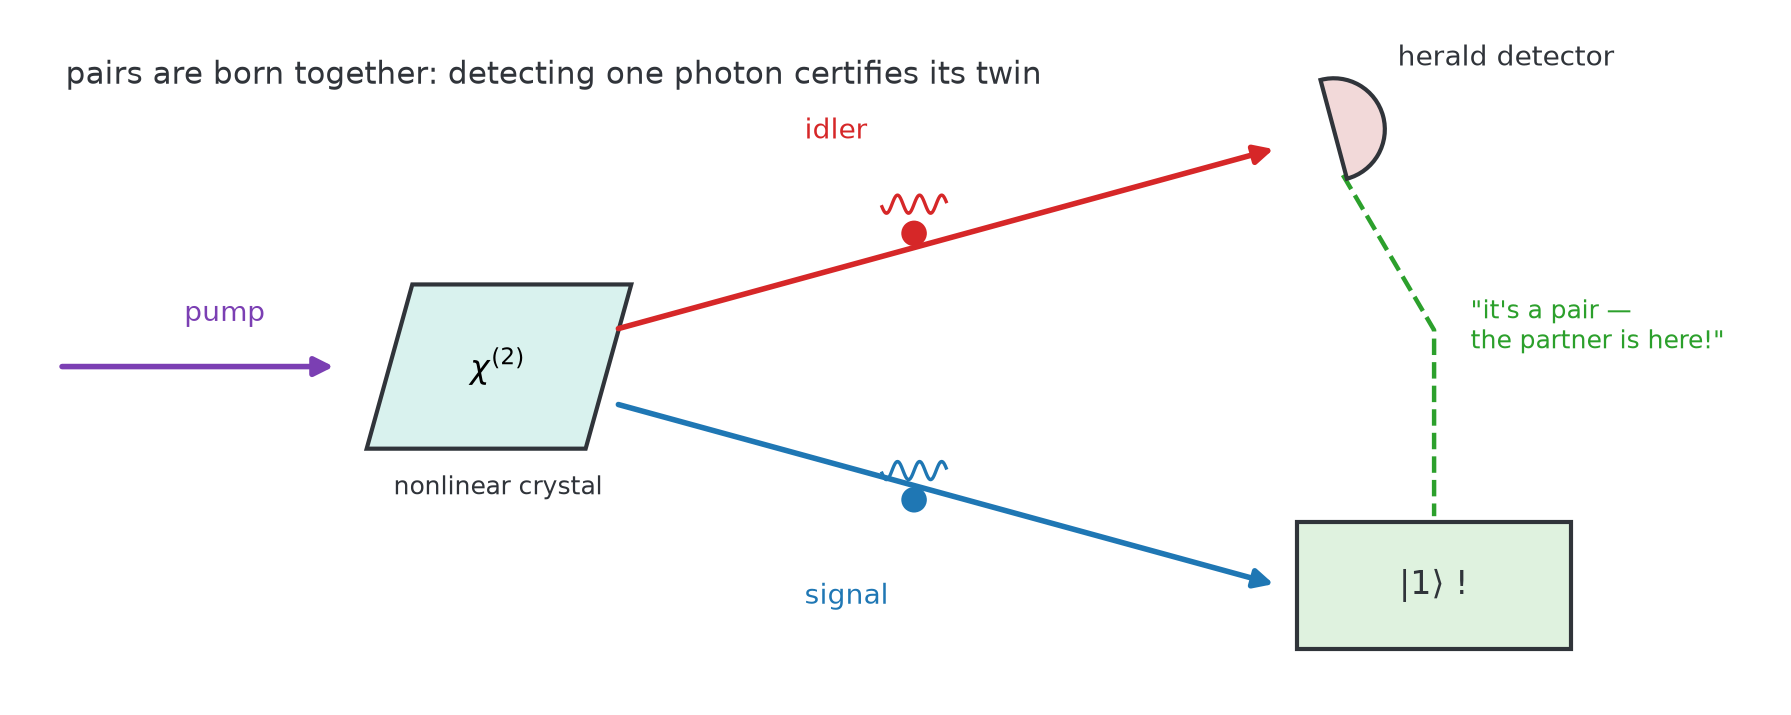

In [2]:
# Course sketch library (auto-fetches itself on Colab, where only
# this notebook exists; a no-op everywhere else).
import importlib.util, os, urllib.request
if importlib.util.find_spec("sketches") is None and not os.path.exists("sketches.py"):
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/laserlab/CountingPhotons"
        "/main/lectures/sketches.py", "sketches.py")
import sketches

sketches.spdc_heralding()

In [3]:
N_MAX = 6   # truncation: keep terms up to |N_MAX, N_MAX> (lambda^6 is tiny)

def tmsv(lam: float, n_extra_modes: int = 0) -> pcvl.StateVector:
    """Two-mode squeezed vacuum sum_n lambda^n |n,n>, truncated at N_MAX.

    Parameters
    ----------
    lam : squeezing parameter lambda in [0, 1) (dimensionless)
    n_extra_modes : number of extra empty modes appended (for loss ancillas)

    Perceval normalizes StateVectors automatically.
    """
    lam = float(lam)   # plain float: numpy scalars confuse StateVector algebra
    sv = pcvl.StateVector()
    for n in range(N_MAX + 1):
        sv += (lam ** n) * pcvl.StateVector(
            pcvl.BasicState([n, n] + [0] * n_extra_modes))
    return sv

# Sanity check: photon-number distribution of the source at lambda = 0.4
lam = 0.4
sim = Simulator(SLOSBackend())
sim.set_circuit(pcvl.Circuit(2))          # empty circuit: just look at the state
dist = sim.probs(tmsv(lam))

print("P(n_signal, n_idler):")
for st, p in sorted(dist.items(), key=lambda kv: -kv[1]):
    if p > 1e-4:
        print(f"  {st}: {p:.4f}")
print("\nonly diagonal terms |n,n> - perfect pair correlation")

P(n_signal, n_idler):
  |0,0>: 0.8400
  |1,1>: 0.1344
  |2,2>: 0.0215
  |3,3>: 0.0034
  |4,4>: 0.0006

only diagonal terms |n,n> - perfect pair correlation


## Exercise 0 · (warm-up) One arm of a pair source is thermal

Tuesday's quiz asserted it; now *prove it numerically*. From the joint distribution `dist` above, compute the **marginal** photon-number distribution of the signal arm alone, $P(n_s) = \sum_{n_i} P(n_s, n_i)$, and show that

1. it matches the Bose–Einstein distribution with $\bar n = \lambda^2/(1-\lambda^2)$,
2. its $g^{(2)}(0) = 2$ — one arm of the world's best-correlated photon source is, by itself, indistinguishable from a lamp.

This is not a curiosity: it is *entanglement seen from one side*. Perfect correlations with an unobserved partner look like maximal noise locally. (The same mathematics makes Hawking radiation thermal [Hawking1975] — which is why a black hole is arguably nature's only *exactly* thermal source: Monday's claim, now with its mechanism.)

*Open-systems language:* ignoring the idler is a **partial trace over an environment**. Maximal entanglement with an unobserved bath = maximal local entropy — the same operation that turns unitary system+bath dynamics into the reduced density matrices and master equations of the other lectures.

In [4]:
# YOUR CODE HERE - Exercise 0
# marginal = ...   (a dict or array over n_signal)
# compare with nbar = lam**2 / (1 - lam**2); compute g2(0) from the marginal


### Aside · Can you tell a black hole from one arm of an SPDC source?

By single-arm photon counting: **no — and exactly, not poetically.** Hawking's derivation is a Bogoliubov transformation that two-mode-squeezes every exterior mode with a partner mode behind the horizon; trace out the partner and each exterior mode is exactly thermal. A black hole *is* nature's down-conversion crystal with the idler arm swallowed — the same mathematics you are running in this exercise. Three things *would* distinguish them:

**1 · The spectrum: one temperature, or one phase-matching curve?** "Thermal" is two different claims. *Per mode* it means Bose–Einstein statistics with some $\bar n$ — both sources pass, in every mode. A *blackbody at temperature $T$* claims far more: all occupations locked to one parameter, $\bar n(\omega) = 1/(e^{\hbar\omega/k_BT} - 1)$. The black hole delivers this — one surface gravity fixes every mode (that universality is why it founded black-hole *thermodynamics*). SPDC does not: $\bar n(\omega) = \sinh^2 r(\omega)$ follows the **phase-matching curve**, not a Planck law. Sharpest test: invert Bose–Einstein per mode into an effective temperature $T_{\rm eff}(\omega) = \hbar\omega / [k_B \ln(1 + 1/\bar n(\omega))]$ — flat for a real thermal bath, a collapsing hump for SPDC (next cell). Statistics *within* a mode cannot distinguish; statistics *across* modes can — the thermal-$2$ lesson from yesterday, one level up.

**2 · Go get the partner.** With SPDC the idler is yours: cross-correlations violate the classical Cauchy–Schwarz bound, heralding works, purity is revealed — the rest of this notebook. For a black hole the partner is behind the horizon *in principle* (that inaccessibility **is** the information paradox, stated operationally). And this measurement has actually been performed in analog gravity: Steinhauer's Bose–Einstein-condensate sonic black hole certified the entanglement of Hawking phonon pairs by measuring correlations **across the horizon** [Steinhauer2016] — signal–idler $g^{(2)}$, on an event horizon.

**3 · Patience (if unitarity holds).** Exact thermality is the semiclassical statement. If evaporation is unitary, late-time Hawking radiation is *not* exactly thermal — the information escapes encoded in correlations **among** the emitted quanta (the Page curve), invisible to every low-order, mode-blind statistic. That is yesterday's $g^{(2)}$ blind-spot lesson at cosmic scale: a source can look perfectly thermal to all local counting while the truth lives in correlations you did not resolve.

**Check yourself:** a colleague hands you a fiber carrying "either filtered Hawking radiation or one arm of my SPDC source." What measurements settle it, in which order, and which single-mode measurement is guaranteed to fail?

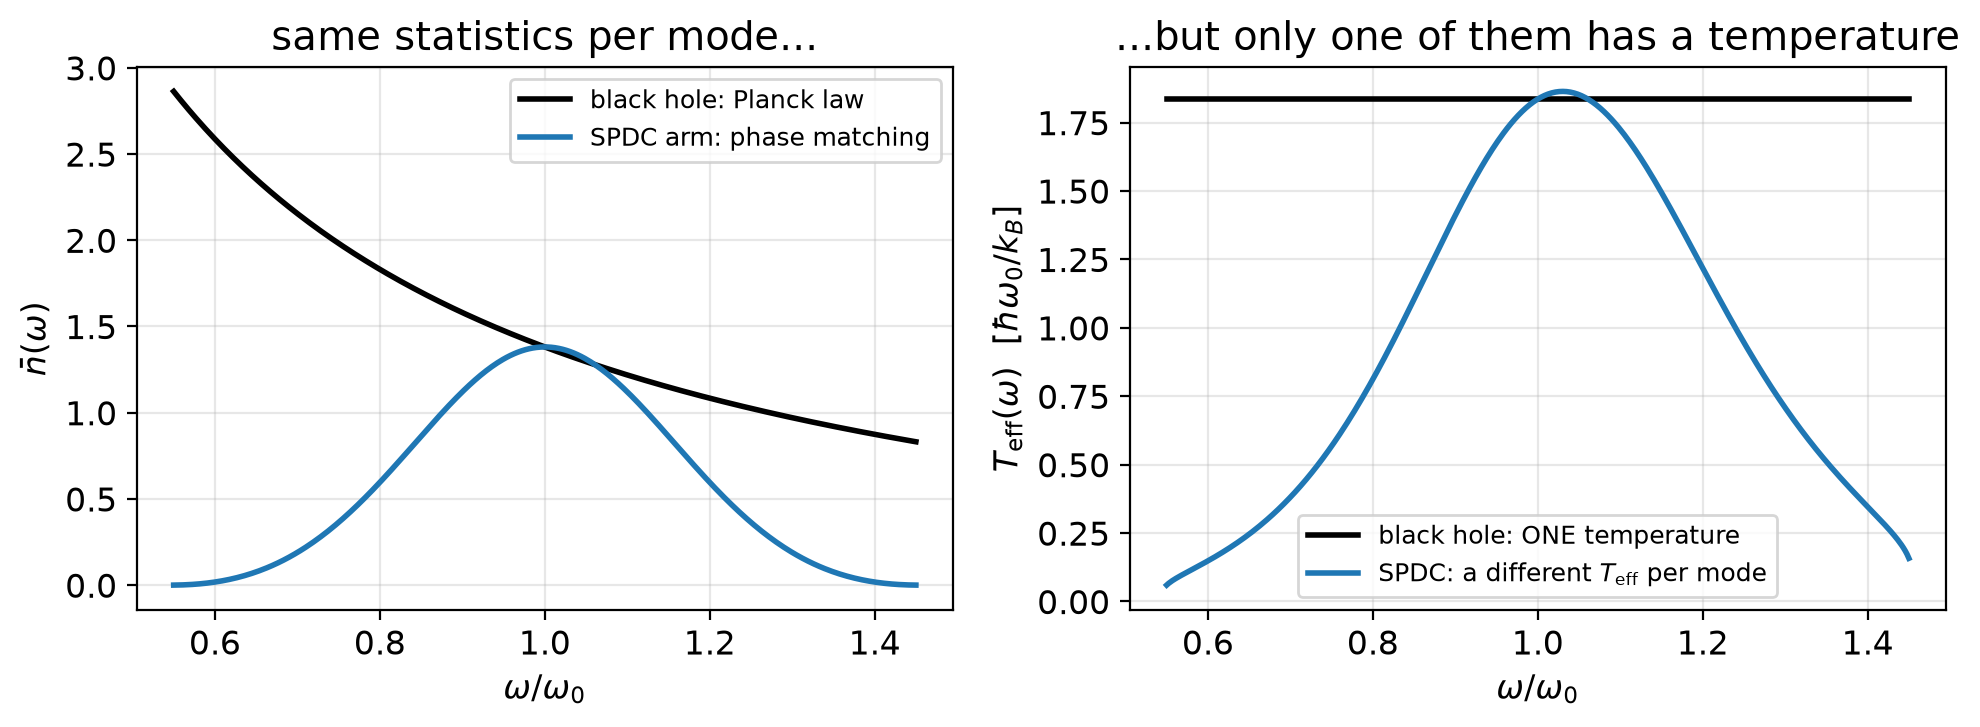

In [5]:
# The T_eff test: one temperature (black hole) vs a phase-matching hump.
w = np.linspace(0.55, 1.45, 400)            # frequency [units of w0]

# SPDC signal arm: nbar = sinh^2 r(w), r follows the phase-matching band
r_w = 1.0 * np.sinc(2.2 * (w - 1.0))        # np.sinc includes the pi
nbar_spdc = np.sinh(np.clip(r_w, 0, None)) ** 2

# blackbody chosen to match the SPDC occupation at band center
nbar0 = np.sinh(1.0) ** 2
T_bb = 1.0 / np.log(1 + 1 / nbar0)          # units hbar w0 / k_B
nbar_bb = 1.0 / (np.exp(w / T_bb) - 1)

def T_eff(nbar):
    """Per-mode effective temperature from inverting Bose-Einstein."""
    return w / np.log(1 + 1 / np.maximum(nbar, 1e-12))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(w, nbar_bb, color="k", lw=2, label="black hole: Planck law")
axes[0].plot(w, nbar_spdc, color="tab:blue", lw=2,
             label="SPDC arm: phase matching")
axes[0].set_xlabel(r"$\omega / \omega_0$")
axes[0].set_ylabel(r"$\bar{n}(\omega)$")
axes[0].set_title("same statistics per mode...")
axes[0].legend(fontsize=9)

axes[1].plot(w, T_eff(nbar_bb), color="k", lw=2,
             label="black hole: ONE temperature")
axes[1].plot(w, T_eff(nbar_spdc), color="tab:blue", lw=2,
             label="SPDC: a different $T_{\\rm eff}$ per mode")
axes[1].set_xlabel(r"$\omega / \omega_0$")
axes[1].set_ylabel(r"$T_{\rm eff}(\omega)$  [$\hbar\omega_0/k_B$]")
axes[1].set_title("...but only one of them has a temperature")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()

**Coda · And where does a star fall on this chart?** On the *black hole's* side: thermal equilibrium is precisely what locks every mode to one temperature, so a star passes the $T_{\rm eff}(\omega)$ test (flat, decorated with absorption lines) while SPDC never does. Which exposes the real punchline — **three completely different mechanisms produce the identical local fingerprint**: a star is chaotic many-emitter light (the $N \to \infty$ limit of Tuesday's independent-emitter formula), SPDC is per-mode pair correlation with no equilibrium anywhere, and a black hole is vacuum entanglement with a partner behind a horizon. Ordinary statistical mechanics takes $10^{57}$ atoms to make thermal light; gravity fakes it from pure vacuum.

**And could HBT at least measure the black hole's *size*, like it measured Sirius?** No — and mass-independently so. The Hawking spectrum peaks at $\lambda_{\rm peak} \approx 28\, r_s$ *for every mass* (both scale with $M$), so a black hole is permanently **sub-wavelength for its own glow**: it emits into a handful of low multipoles — after greybody filtering, mostly the single, spatially coherent $s$-wave. A one-mode far field never decorrelates with baseline, so an intensity interferometer reads "point source" at any separation. (Careful with the tempting wrong reason: it is *not* that the source is a perfect sphere — a star is round too, yet its limbs emit *uncorrelated* light, which is exactly what HBT exploited. Symmetry constrains the average intensity; coherence is about independent emitting patches, and a source of radius $R$ simply cannot imprint angular structure finer than $\Delta\theta \sim \lambda/2\pi R$ — for the black hole that is coarser than the whole sky, so "sides" do not exist as independent degrees of freedom. Bonus quantum layer: within the $s$-wave, one Hawking photon is a spherical amplitude over all directions — detected on the left, it is not on the right. Opposite sides *anti*-correlate photon by photon and correlate in intensity: Grangier's beamsplitter anticorrelation, performed on a sphere.) Contrast Sirius: $10^{15}$ wavelengths across, myriad incoherent patches, coherence dying at $d \sim \lambda/\theta$ — HBT's bread and butter. The compensation is exact and is the **no-hair theorem in photon-statistics language**: for a star the spectrum gives $T$ but not $R$ (you need HBT because a star has hair — spots, limb darkening, oblateness); for a black hole $T_H \propto 1/M$ means the spectrum alone hands you the mass and hence the size, and no-hair guarantees there is nothing else to map. HBT is not defeated by the black hole — it is *redundant*. (When astronomers do interfere light "from a black hole" — the EHT photon ring — they are imaging the accretion plasma: ordinary chaotic light, many wavelengths across, where interferometry works exactly as it does on a star.)

## 6.2 · Worked example: heralding an ideal single photon

Put a **photon-number-resolving detector** in the idler arm. Keep only the runs where it fires with exactly 1 photon. What is the signal state on those runs?

(This is not a thought experiment: Hong and Mandel did it in 1986 [HongMandel1986] — the first heralded single photon, one year before their interference experiment. The heralding idea is the workhorse of quantum optics to this day.)

In [6]:
def heralded_signal_distribution(dist, idler_mode: int = 1,
                                 herald_condition=lambda n: n == 1):
    """Signal photon-number distribution conditioned on an idler outcome.

    Parameters
    ----------
    dist : Perceval probability distribution over BasicStates
    idler_mode : index of the mode carrying the herald detector
    herald_condition : function n_idler -> bool defining the herald

    Returns
    -------
    P_heralded : dict n_signal -> conditional probability
    P_herald : total probability that the herald fires (the source "brightness")
    """
    joint = defaultdict(float)
    for st, p in dist.items():
        if herald_condition(st[idler_mode]):
            joint[st[0]] += p
    P_herald = sum(joint.values())
    return {n: p / P_herald for n, p in sorted(joint.items())}, P_herald


def g2_from_distribution(P: dict) -> float:
    """g2(0) = <n(n-1)>/<n>^2 from a photon-number distribution dict."""
    mean = sum(n * p for n, p in P.items())
    pairs = sum(n * (n - 1) * p for n, p in P.items())
    return pairs / mean ** 2


P_h, brightness = heralded_signal_distribution(dist)
print(f"lambda = {lam}, ideal PNR herald on n_idler = 1:")
print(f"  P(herald fires) = {brightness:.4f}")
print(f"  P(n_signal | herald) = {P_h}")
print(f"  heralded g2(0) = {g2_from_distribution(P_h):.4f}")

lambda = 0.4, ideal PNR herald on n_idler = 1:
  P(herald fires) = 0.1344
  P(n_signal | herald) = {1: 1.0}
  heralded g2(0) = 0.0000


A **perfect** single photon: $P(1|{\rm herald}) = 1$, $g^{(2)}(0) = 0$. Too good to be true — and indeed it is, twice over:

1. real idler detectors miss photons (**loss**): a 2-pair event where one idler photon is lost looks *exactly* like a 1-pair event → the "single photon" is secretly $|2\rangle$ sometimes;
2. most real detectors are **click detectors** (SPAD/SNSPD without multiplexing): they say "≥ 1 photon", not "exactly 1".

## 6.3 · Loss = a beamsplitter to a mode nobody watches

The standard trick (you met it Monday as binomial thinning): transmission $\eta$ is a beamsplitter with reflectivity $1-\eta$ routing photons into an extra *loss mode* that is traced over. Let's add an idler loss mode:

```
mode 0: signal ────────────────────
mode 1: idler ────BS(η_i)────────── PNR/click herald
mode 2: (loss)       └────────────  nobody looks here
```

In [7]:
def spdc_with_idler_loss(lam: float, eta_idler: float):
    """Joint output distribution of a TMSV with idler transmission eta_idler.

    Mode layout: 0 = signal, 1 = idler (detected), 2 = idler loss mode.
    """
    circuit = pcvl.Circuit(3)
    # reflectivity = eta: probability eta that the idler photon STAYS in mode 1
    circuit.add((1, 2), pcvl.BS(theta=pcvl.BS.r_to_theta(eta_idler)))
    sim = Simulator(SLOSBackend())
    sim.set_circuit(circuit)
    return sim.probs(tmsv(lam, n_extra_modes=1))


def marginal_over_loss(dist):
    """Sum probabilities over the unobserved loss mode (mode 2)."""
    out = defaultdict(float)
    for st, p in dist.items():
        out[(st[0], st[1])] += p   # keep (signal, detected idler) only
    return out


# Heralded state with a lossy PNR idler detector, eta = 0.6:
dist3 = marginal_over_loss(spdc_with_idler_loss(lam=0.4, eta_idler=0.6))
joint = defaultdict(float)
for (n_s, n_i), p in dist3.items():
    if n_i == 1:                       # PNR herald: exactly one idler DETECTED
        joint[n_s] += p
brightness = sum(joint.values())
P_h = {n: p / brightness for n, p in sorted(joint.items())}

print(f"lambda = 0.4, eta_idler = 0.6, PNR herald on 1 detected photon:")
print(f"  P(herald) = {brightness:.4f}")
for n, p in P_h.items():
    print(f"  P(n_signal = {n} | herald) = {p:.4f}")
print(f"  heralded g2(0) = {g2_from_distribution(P_h):.4f}")

lambda = 0.4, eta_idler = 0.6, PNR herald on 1 detected photon:
  P(herald) = 0.0920
  P(n_signal = 1 | herald) = 0.8761
  P(n_signal = 2 | herald) = 0.1121
  P(n_signal = 3 | herald) = 0.0108
  P(n_signal = 4 | herald) = 0.0009
  P(n_signal = 5 | herald) = 0.0001
  P(n_signal = 6 | herald) = 0.0000
  heralded g2(0) = 0.2334


There it is: the herald *fired on exactly one photon*, yet the signal contains $|2\rangle$ (and worse) with several percent probability — the partner of the lost idler photon. The heralded $g^{(2)}(0)$ is no longer 0.

## 6.4 · The design challenge (25 min, small groups)

You are building a heralded single-photon source for a quantum network. Fixed hardware:

* idler transmission $\eta_i = 0.6$ (fiber + detector),
* the herald detector is a **click detector**: it fires for *any* $n_{\rm detected} \ge 1$,
* your only knob is the **pump power**, i.e. $\lambda \in (0, 0.9)$.

The trade-off you must quantify: cranking $\lambda$ up gives more heralds (brightness ↑) but more multi-pair contamination (purity ↓). Define

$$\begin{gathered}\text{FOM}(\lambda) = \underbrace{P(\text{herald fires})}_{\text{brightness } B}\;\times\\[3pt]
\underbrace{P(n_s = 1 \mid \text{herald})}_{\text{single-photon purity } \Pi}\end{gathered}$$

**Tasks:**
1. implement the click-detector herald ($n_i \ge 1$ detected),
2. plot $B(\lambda)$, $\Pi(\lambda)$, and FOM($\lambda$) for $\lambda \in [0.05, 0.9]$,
3. report: your optimal $\lambda$, and the heralded $g^{(2)}(0)$ at that operating point — does your optimized source still pass the $g^{(2)}(0) < 0.5$ certificate from yesterday?
4. **group competition:** highest FOM *subject to* heralded $g^{(2)}(0) < 0.1$ wins. (You may now also assume a better detector, $\eta_i$ up to 0.95 — money buys performance. Does the optimal $\lambda$ move up or down?)

In [8]:
# YOUR CODE HERE - design challenge
lambdas = np.linspace(0.05, 0.9, 18)


## 6.5 · Worked finale: heralding $|2\rangle$

With a PNR herald (a TES, or a multiplexed SNSPD) you can post-select $n_i = 2$ and prepare **two-photon Fock states** — exactly what [Cooper2013] did in the lab up to $n = 3$. The fingerprint of $|2\rangle$: $g^{(2)}(0) = 1 - 1/2 = 0.5$ (Monday's formula).

In [9]:
# Herald on exactly 2 detected idler photons (ideal PNR, no loss for clarity).
sim = Simulator(SLOSBackend())
sim.set_circuit(pcvl.Circuit(2))
dist = sim.probs(tmsv(0.5))

P_h2, brightness2 = heralded_signal_distribution(
    dist, herald_condition=lambda n: n == 2)
print(f"PNR herald on n_idler = 2 (lambda = 0.5):")
print(f"  P(herald) = {brightness2:.4f}")
print(f"  P(n_signal | herald) = {P_h2}")
print(f"  heralded g2(0) = {g2_from_distribution(P_h2):.3f}   (theory: 0.5)")

PNR herald on n_idler = 2 (lambda = 0.5):
  P(herald) = 0.0469
  P(n_signal | herald) = {2: 1.0}
  heralded g2(0) = 0.500   (theory: 0.5)


## 6.6 · Finale: boson sampling in sixty seconds

Why did the world build photonic quantum computers out of *exactly* the parts in this course? A three-step history:

* **2001 — KLM** [Knill2001]: Knill, Laflamme and Milburn prove that single photons + linear optics + photon counting + feedforward are enough for **universal** quantum computing. Shocking at the time: beamsplitters don't interact photons, yet measurement supplies the missing nonlinearity. (The HOM effect is the engine.)
* **2011 — Aaronson & Arkhipov** [Aaronson2011]: even *without* feedforward, just sampling the outputs of $n$ photons in a random $m$-mode interferometer is classically intractable — output amplitudes are matrix **permanents**, and computing permanents is #P-hard (provably so for *exact* sampling; for the realistic noisy case modulo two plausible conjectures). A dumbed-down photonic machine still beats classical computers at its own (admittedly useless) game.
* **2020 — Jiuzhang** [Zhong2020]: 50 single-mode squeezed states injected into a 100-mode interferometer, 43 photons detected on average (up to 76), quantum advantage claimed — the states from *this notebook*, interfering as in *this morning's notebook*, counted by the detectors of *Tuesday's lecture*. (2022 — **Borealis** [Madsen2022] made the interferometer *programmable*, with photon-number-resolving readout of up to 219 photons.)

Here is boson sampling, at a size your laptop still wins:

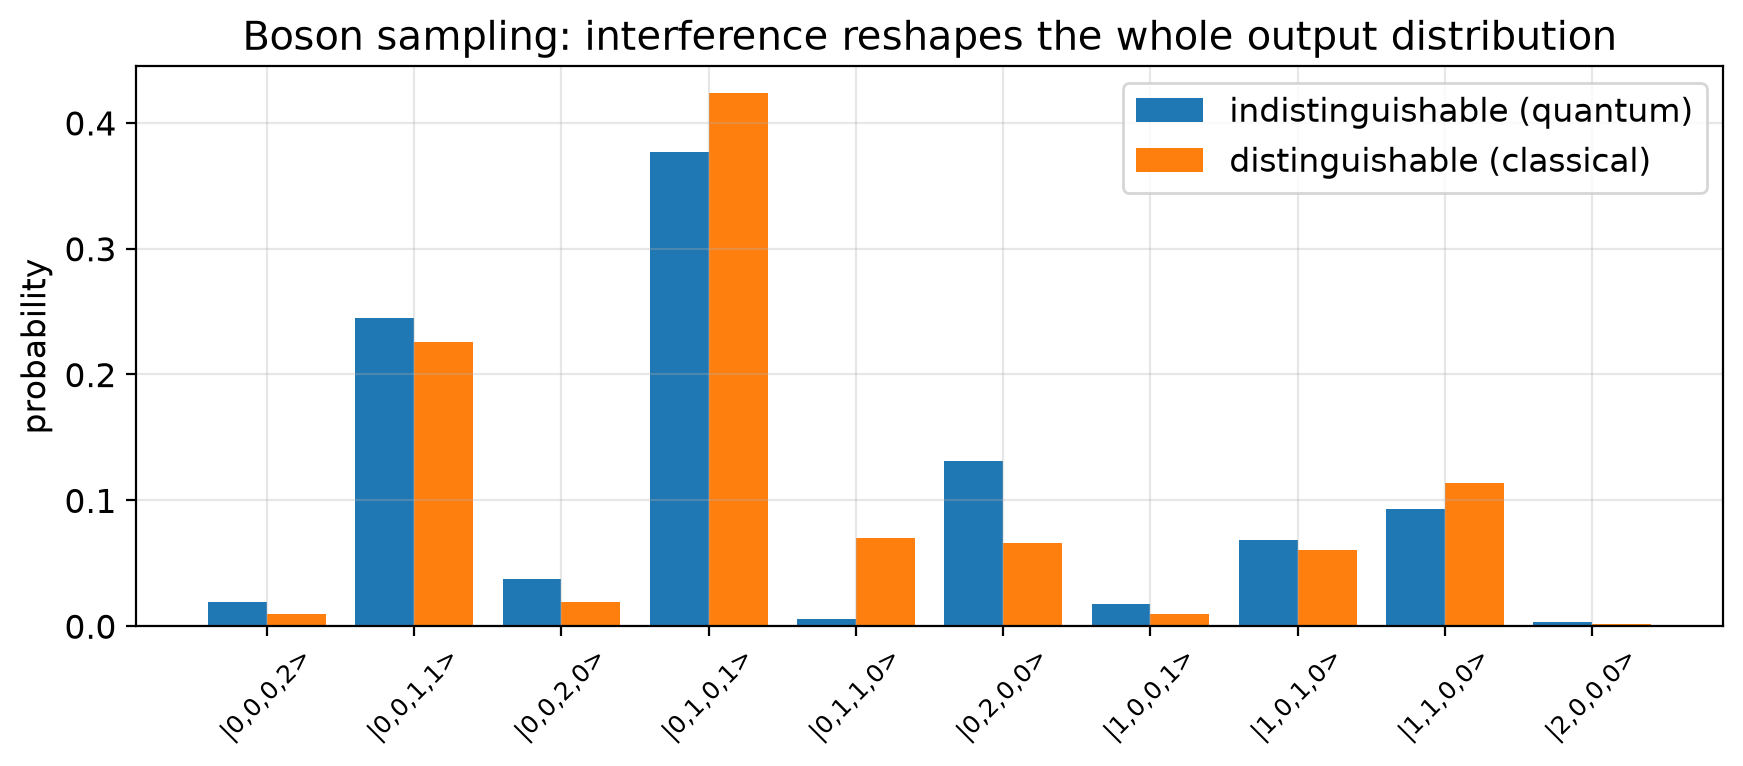

In [10]:
# Boson sampling, minimal edition: 2 photons in a random 4-mode circuit.
np.random.seed(6)                              # fixed Haar-random unitary
U = pcvl.Matrix.random_unitary(4)
circuit_bs = pcvl.Circuit(4).add(0, pcvl.Unitary(U))

def output_distribution(indistinguishability: float):
    """Output distribution of |1,1,0,0> through the random interferometer."""
    proc = pcvl.Processor("SLOS", circuit_bs,
                          noise=pcvl.NoiseModel(
                              indistinguishability=indistinguishability))
    proc.with_input(pcvl.BasicState([1, 1, 0, 0]))
    proc.min_detected_photons_filter(2)
    return pcvl.algorithm.Sampler(proc).probs()["results"]

quantum = output_distribution(1.0)     # indistinguishable photons: permanents
classical = output_distribution(0.0)   # distinguishable photons: just combinatorics

labels = sorted(set(quantum) | set(classical), key=str)
x = np.arange(len(labels))
plt.figure(figsize=(9, 4))
plt.bar(x - 0.2, [quantum.get(s, 0) for s in labels], 0.4,
        label="indistinguishable (quantum)")
plt.bar(x + 0.2, [classical.get(s, 0) for s in labels], 0.4,
        label="distinguishable (classical)")
plt.xticks(x, [str(s) for s in labels], rotation=45, fontsize=9)
plt.ylabel("probability")
plt.title("Boson sampling: interference reshapes the whole output distribution")
plt.legend()
plt.tight_layout()
plt.show()
# Every quantum bar is |permanent of a 2x2 submatrix of U|^2. At ~50
# detected photons in 100 modes those permanents defeat every classical
# supercomputer - that, and nothing else, was the 2020 advantage claim.

Note what the comparison shows: with photons made **distinguishable** (the `indistinguishability=0` noise model — think 'arriving at different times'), the distribution collapses to classical combinatorics. The entire computational power lives in the HOM-type interference you measured this morning. *Distinguishability is the off-switch of photonic quantum computing.*

## 6.7 · Wrap-up: you now own the toolbox

Three days, one coherent story:

| day | concept | tool |
|---|---|---|
| Mon | photon statistics $P(n)$, Mandel $Q$ | QuTiP |
| Tue | correlations $g^{(2)}$, HBT, sources & detectors | time-tag analysis |
| Wed | HOM interference · heralded Fock states | Perceval |

These are precisely the primitives of **photonic quantum computing**: heralded sources (today), interference in programmable interferometers (this morning), photon-number-resolving detection (Tuesday). Scale it up and you get boson sampling [Zhong2020] and measurement-based photonic quantum computers — the machines Perceval was built to program [Heurtel2023].

**Where to go from here**

* *Books:* Fox [Fox2006] (accessible), Gerry & Knight [GerryKnight2005] (thorough), Loudon [Loudon2000] (the classic).
* *Reviews:* [Bouchard2021] (HOM), [MeyerScott2020] (sources), [Natarajan2012] (detectors).
* *Play:* the [Perceval documentation](https://perceval.quandela.net/docs/) has tutorials from HOM to full boson sampling — everything you built today scales.

## Take it home

All notebooks, exercises, and sample solutions stay online after the school — keep working through them at your own pace; **nothing needs to be handed in.** Tell me your group's best FOM from today's challenge — winners announced at the discussion session. **Obrigado & keep counting photons!**

---
---

# Sample solutions

**No peeking during the session.**

And the catch you quantified yourself today — every component is lossy, and loss is photonics' dominant error channel — is exactly why **quantum error correction** dominates the photonic-QC agenda: this school's error-correction lectures pick up precisely where our figure-of-merit plot left off.

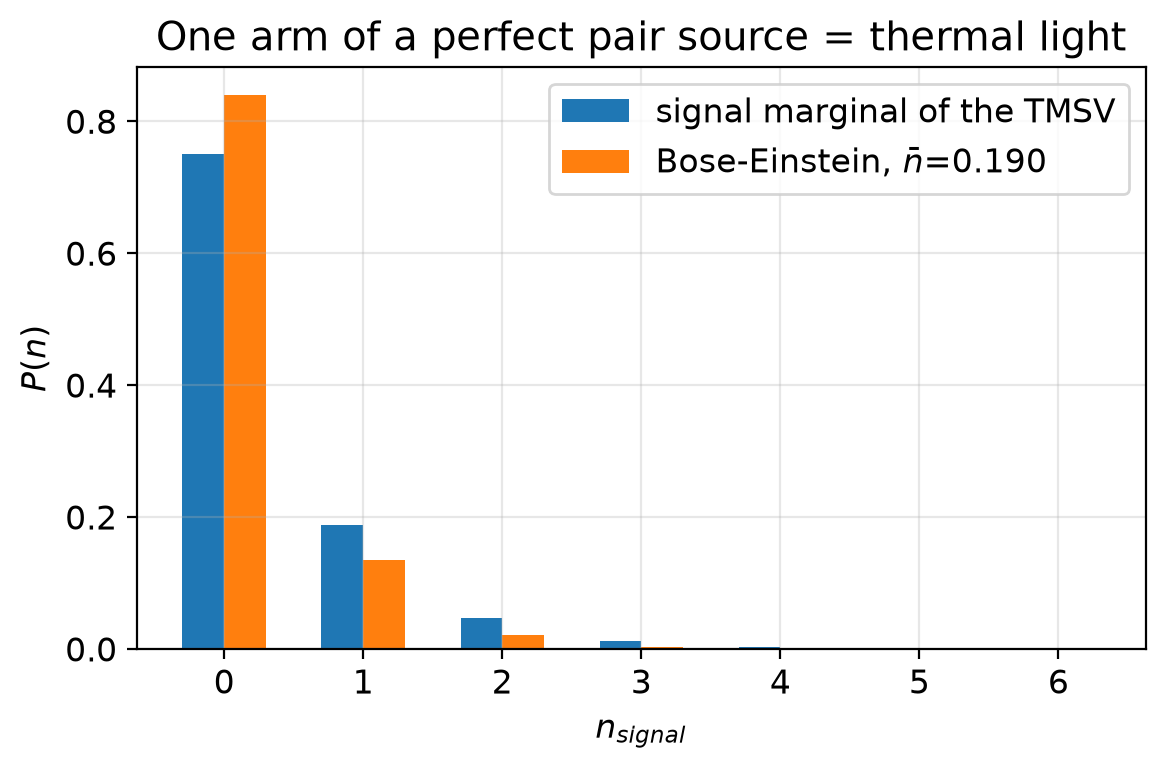

marginal g2(0) = 1.979   (thermal: 2)


In [11]:
# Solution - Exercise 0
marginal = defaultdict(float)
for st, p in dist.items():
    marginal[st[0]] += p          # sum over the idler outcome

n_vals = np.array(sorted(marginal))
P_marg = np.array([marginal[n] for n in n_vals])
nbar_th = lam**2 / (1 - lam**2)
P_BE = nbar_th**n_vals / (1 + nbar_th)**(n_vals + 1)

plt.bar(n_vals - 0.15, P_marg, 0.3, label="signal marginal of the TMSV")
plt.bar(n_vals + 0.15, P_BE, 0.3, label=f"Bose-Einstein, $\\bar n$={nbar_th:.3f}")
plt.xlabel("$n_{signal}$"); plt.ylabel("$P(n)$")
plt.title("One arm of a perfect pair source = thermal light")
plt.legend(); plt.tight_layout(); plt.show()

mean = sum(n * p for n, p in marginal.items())
pairs = sum(n * (n - 1) * p for n, p in marginal.items())
print(f"marginal g2(0) = {pairs / mean**2:.3f}   (thermal: 2)")
# Entanglement seen from one side is indistinguishable from noise: the
# signal-idler correlations only reappear when you CONDITION on the idler
# (heralding - the rest of this notebook).

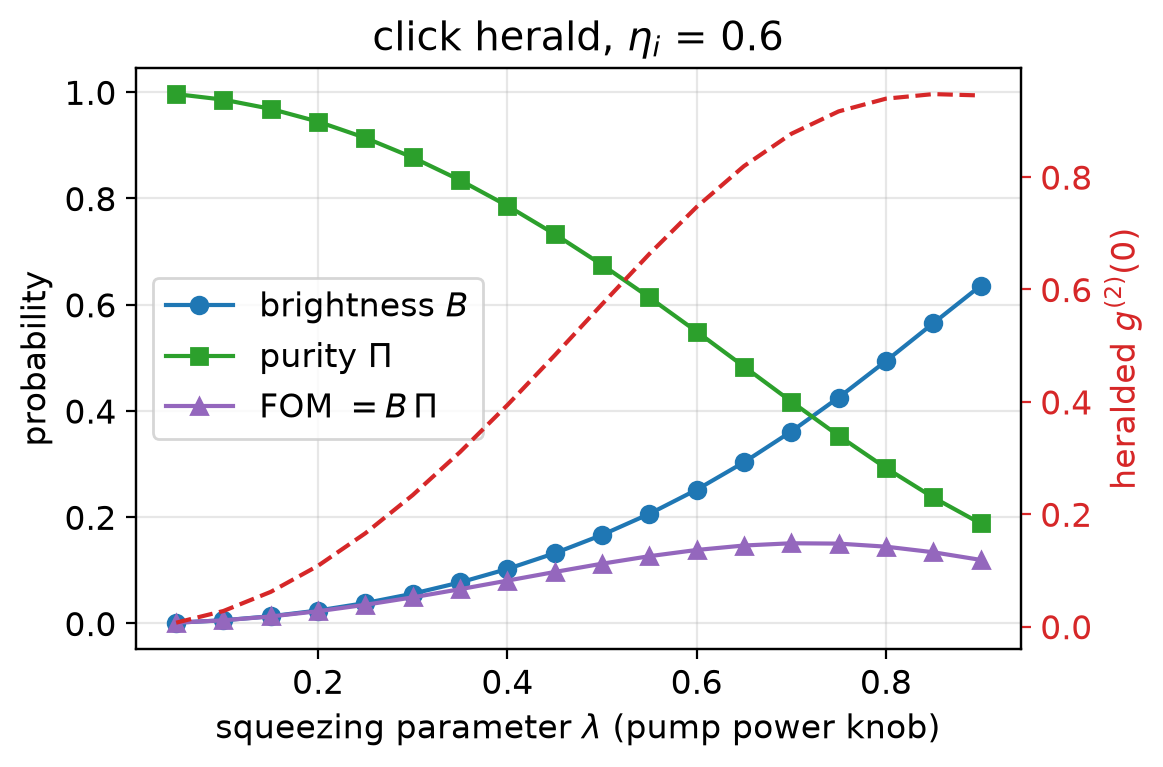

optimal lambda = 0.70: FOM = 0.151, heralded g2(0) = 0.877
best FOM with g2 < 0.1 constraint: lambda = 0.15, FOM = 0.013, g2(0) = 0.062


In [12]:
# Solution - design challenge
def click_herald_source(lam: float, eta_idler: float):
    """Brightness, purity, and heralded g2(0) for a click-detector herald.

    Returns (B, purity, g2_heralded).
    """
    dist = marginal_over_loss(spdc_with_idler_loss(lam, eta_idler))
    joint = defaultdict(float)
    for (n_s, n_i), p in dist.items():
        if n_i >= 1:                   # click detector: any detected photon
            joint[n_s] += p
    B = sum(joint.values())
    P_h = {n: p / B for n, p in joint.items()}
    return B, P_h.get(1, 0.0), g2_from_distribution(P_h)


lambdas = np.linspace(0.05, 0.9, 18)
eta_i = 0.6
results = np.array([click_herald_source(lam, eta_i) for lam in lambdas])
B, purity, g2_h = results.T
fom = B * purity

fig, ax1 = plt.subplots()
ax1.plot(lambdas, B, "o-", color="tab:blue", label="brightness $B$")
ax1.plot(lambdas, purity, "s-", color="tab:green", label=r"purity $\Pi$")
ax1.plot(lambdas, fom, "^-", color="tab:purple", label=r"FOM $= B\,\Pi$")
ax1.set_xlabel(r"squeezing parameter $\lambda$ (pump power knob)")
ax1.set_ylabel("probability")
ax1.legend(loc="center left")
ax2 = ax1.twinx()
ax2.plot(lambdas, g2_h, "--", color="tab:red")
ax2.set_ylabel(r"heralded $g^{(2)}(0)$", color="tab:red")
ax2.tick_params(axis="y", colors="tab:red")
ax2.grid(False)
plt.title(f"click herald, $\\eta_i$ = {eta_i}")
plt.tight_layout(); plt.show()

best = np.argmax(fom)
print(f"optimal lambda = {lambdas[best]:.2f}: "
      f"FOM = {fom[best]:.3f}, heralded g2(0) = {g2_h[best]:.3f}")
ok = g2_h < 0.1
if ok.any():
    best_c = np.where(ok, fom, 0).argmax()
    print(f"best FOM with g2 < 0.1 constraint: lambda = {lambdas[best_c]:.2f}, "
          f"FOM = {fom[best_c]:.3f}, g2(0) = {g2_h[best_c]:.3f}")
# With a better detector (eta_i -> 0.95) the g2 penalty per lambda shrinks,
# so the constrained optimum moves to HIGHER lambda: better detectors let
# you pump harder. Efficiency is everything - again.